# Per-Language Deduplication Rate Visualization

Reads results from `results/language_dedup.json` and produces three figures.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight"})

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

with open("../results/language_dedup.json") as f:
    data = json.load(f)

languages = data["languages"]
print(f"Loaded results for {len(languages)} languages")

Loaded results for 14 languages


In [2]:
# Build DataFrame
rows = []
for lang, info in languages.items():
    rows.append({
        "language": lang,
        "dedup_rate": info["dedup_rate"],
        "token_removal_rate": info["token_removal_rate"],
        "n_files_input": info["n_files_input"],
        "n_files_kept": info["n_files_kept"],
        "max_component_size": info["max_component_size"],
        "mean_component_size": info["mean_component_size"],
    })
df = pd.DataFrame(rows).sort_values("dedup_rate", ascending=True).reset_index(drop=True)

# Language category colors
CATEGORY = {
    "html": "web", "css": "web", "javascript": "web", "typescript": "web", "php": "web",
    "python": "scripting", "shell": "scripting", "lua": "scripting",
    "c": "systems", "cpp": "systems", "rust": "systems",
    "java": "jvm",
    "haskell": "functional", "julia": "functional",
}
PALETTE = {
    "web": "#e74c3c",
    "scripting": "#3498db",
    "systems": "#2ecc71",
    "jvm": "#f39c12",
    "functional": "#9b59b6",
}
df["category"] = df["language"].map(CATEGORY)
df["color"] = df["category"].map(PALETTE)

df

,language,dedup_rate,token_removal_rate,n_files_input,n_files_kept,max_component_size,mean_component_size,category,color
0,javascript,0.0382,0.1784,200000,192361,214,13.66,web,#e74c3c
1,python,0.0553,0.0770,200000,188938,579,63.84,scripting,#3498db
2,java,0.0590,0.0636,200000,188199,706,119.14,jvm,#f39c12
3,c,0.0710,0.1239,200000,185806,631,29.47,systems,#2ecc71
4,typescript,0.0750,0.2969,200000,184996,1330,195.68,web,#e74c3c
5,cpp,0.0953,0.1657,200000,180935,723,35.10,systems,#2ecc71
6,php,0.1102,0.1761,200000,177969,3114,462.82,web,#e74c3c
7,shell,0.1285,0.2402,200000,174302,1936,222.73,scripting,#3498db
8,rust,0.1374,0.2517,200000,172514,913,49.80,systems,#2ecc71
9,haskell,0.1505,0.3571,200000,169900,1175,35.99,functional,#9b59b6


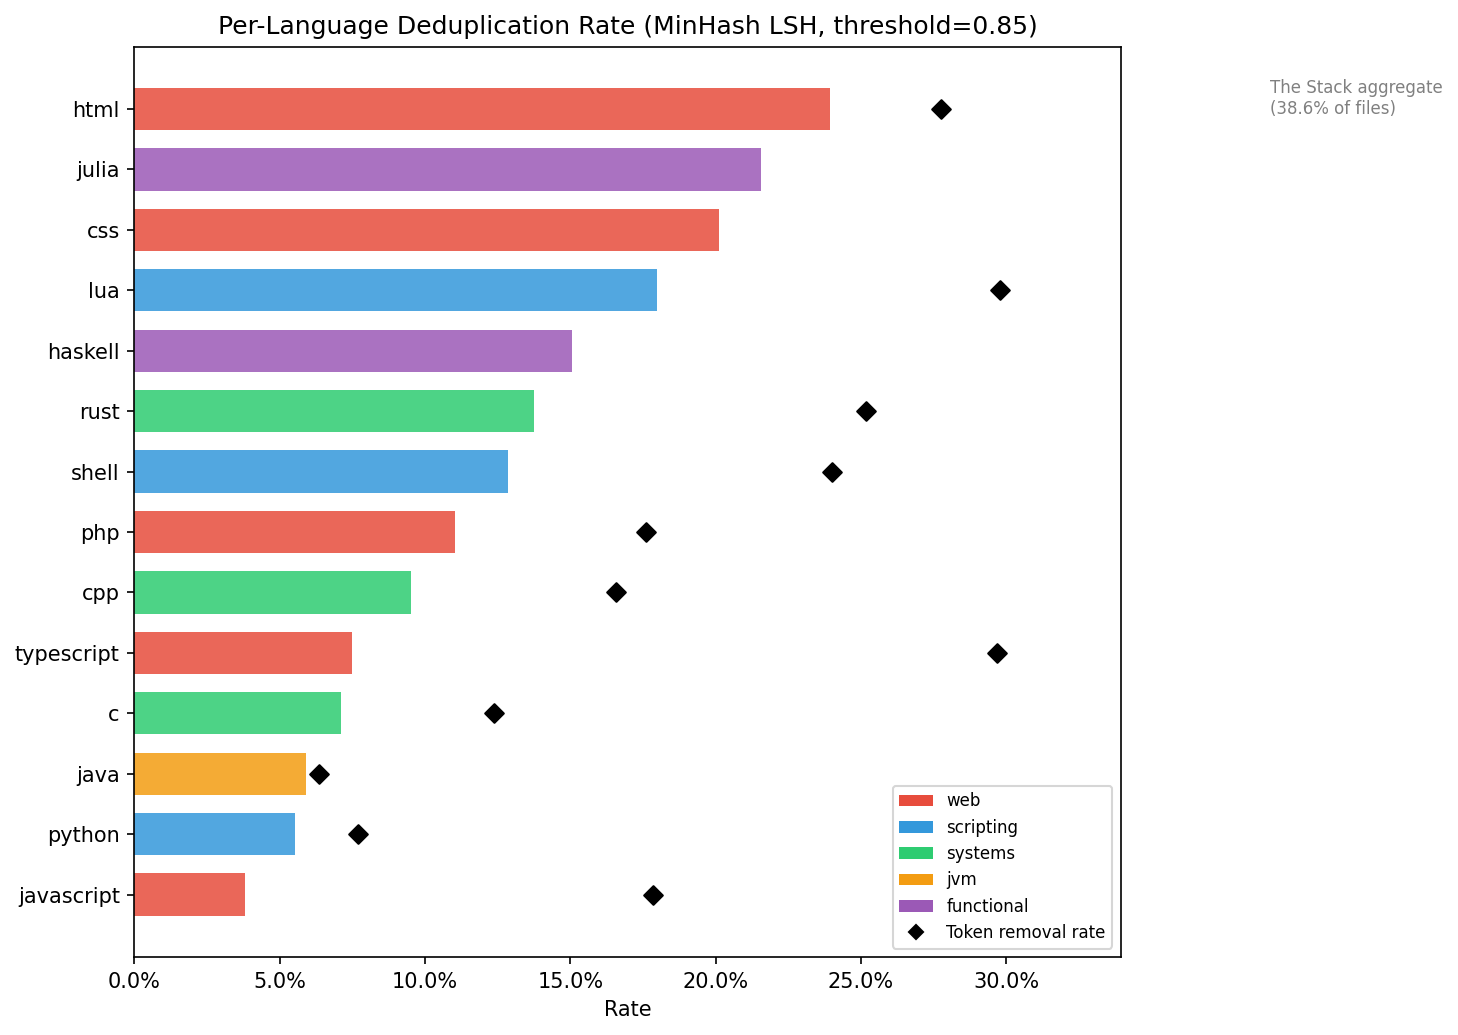

Saved to ../figures/fig1_dedup_rates.png


In [3]:
# Figure 1 — Dedup rate bar chart
fig, ax = plt.subplots(figsize=(10, 7))

y_pos = range(len(df))
ax.barh(y_pos, df["dedup_rate"], color=df["color"], alpha=0.85, height=0.7, label="File dedup rate")
ax.scatter(df["token_removal_rate"], y_pos, color="black", zorder=5, s=40, marker="D", label="Token removal rate")

# Reference line at 38.6%
ax.axvline(x=0.386, color="gray", linestyle="--", linewidth=1.2)
ax.text(0.386 + 0.005, len(df) - 0.5, "The Stack aggregate\n(38.6% of files)",
        fontsize=8, color="gray", va="top")

ax.set_yticks(y_pos)
ax.set_yticklabels(df["language"])
ax.set_xlabel("Rate")
ax.set_title("Per-Language Deduplication Rate (MinHash LSH, threshold=0.85)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_xlim(0, min(1.0, df["dedup_rate"].max() + 0.1))

# Legend for categories
from matplotlib.patches import Patch
handles = [Patch(facecolor=PALETTE[c], label=c) for c in PALETTE]
handles.append(plt.Line2D([0], [0], marker="D", color="black", linestyle="None", markersize=5, label="Token removal rate"))
ax.legend(handles=handles, loc="lower right", fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig1_dedup_rates.png")
plt.show()
print(f"Saved to {FIGURES_DIR / 'fig1_dedup_rates.png'}")

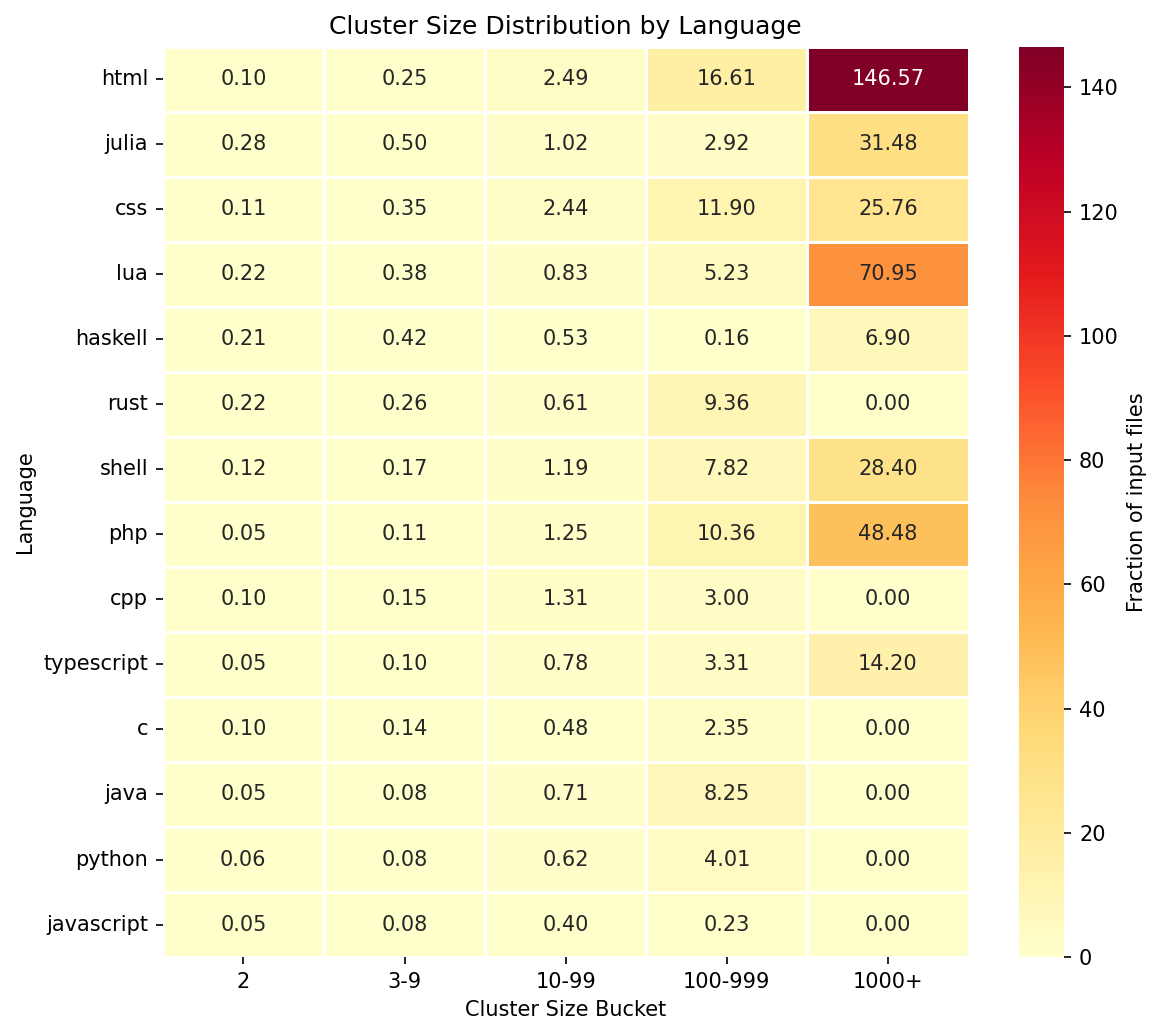

Saved to ../figures/fig2_cluster_heatmap.png


In [4]:
# Figure 2 — Cluster size distribution heatmap
bucket_keys = ["size_2", "size_3_9", "size_10_99", "size_100_999", "size_1000_plus"]
bucket_labels = ["2", "3-9", "10-99", "100-999", "1000+"]

# Sort languages by dedup rate (highest at top for heatmap)
df_sorted = df.sort_values("dedup_rate", ascending=False).reset_index(drop=True)

heatmap_data = []
for _, row in df_sorted.iterrows():
    lang = row["language"]
    dist = languages[lang]["cluster_size_distribution"]
    heatmap_data.append([dist[k]["fraction_of_files"] for k in bucket_keys])

heatmap_df = pd.DataFrame(heatmap_data, index=df_sorted["language"], columns=bucket_labels)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Fraction of input files"},
)
ax.set_xlabel("Cluster Size Bucket")
ax.set_ylabel("Language")
ax.set_title("Cluster Size Distribution by Language")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_cluster_heatmap.png")
plt.show()
print(f"Saved to {FIGURES_DIR / 'fig2_cluster_heatmap.png'}")

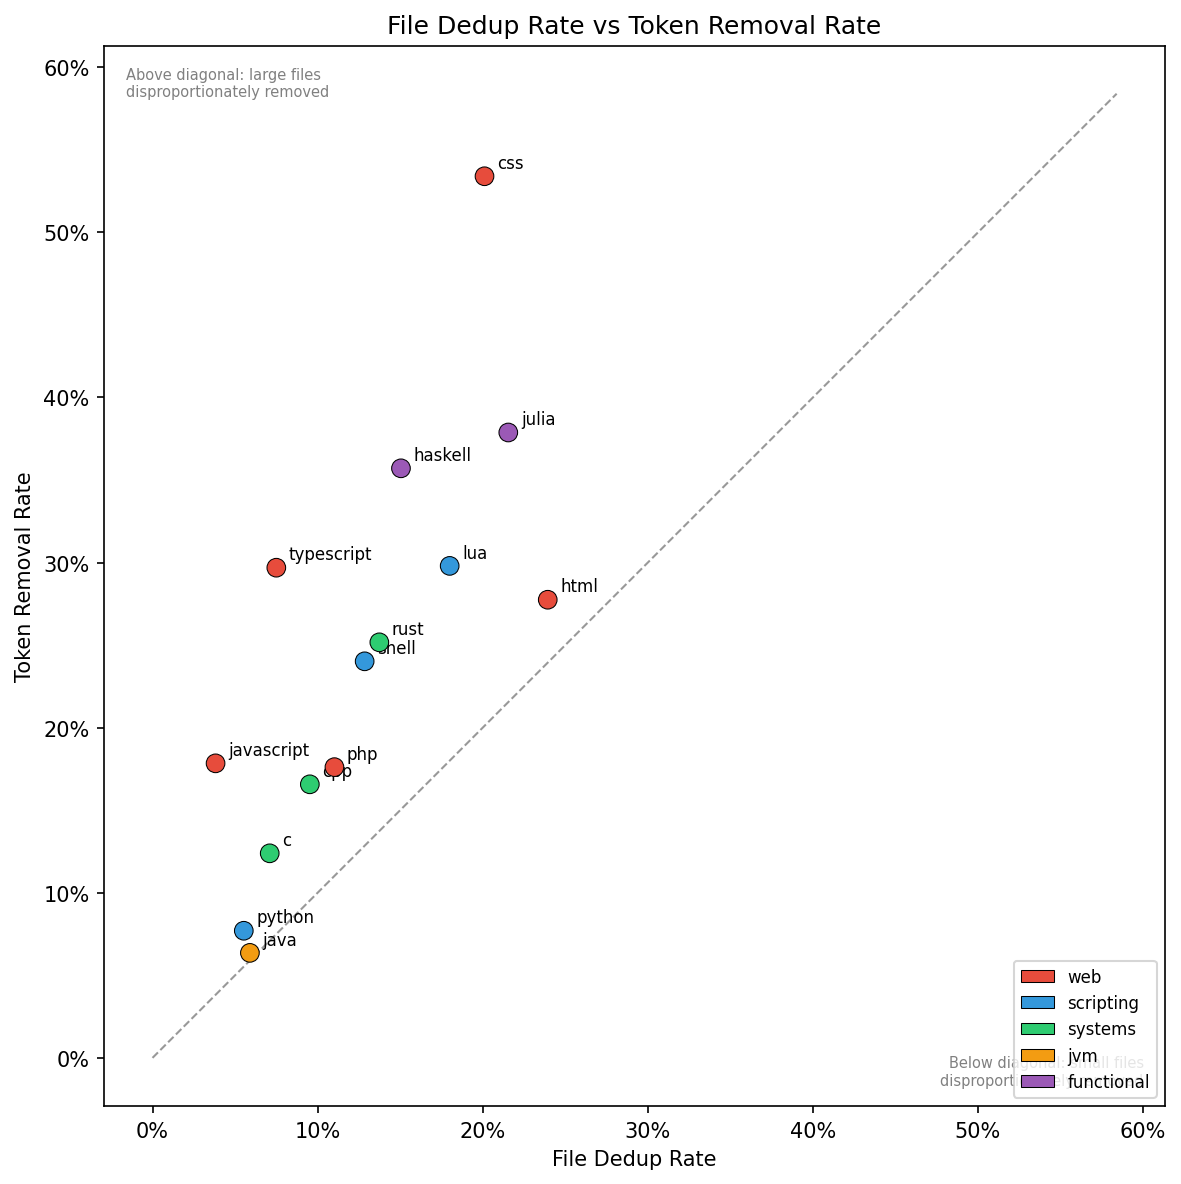

Saved to ../figures/fig3_file_vs_token_rate.png

Note: Token counts for minified HTML/JS are overcounted by the whitespace-split method.
This affects magnitude but not the direction of above/below-diagonal findings.


In [5]:
# Figure 3 — File dedup rate vs token removal rate scatter
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(df["dedup_rate"], df["token_removal_rate"], c=df["color"], s=80, zorder=5, edgecolors="black", linewidth=0.5)

# Label each point
for _, row in df.iterrows():
    ax.annotate(
        row["language"],
        (row["dedup_rate"], row["token_removal_rate"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )

# Diagonal reference line y = x
lims = [0, max(df["dedup_rate"].max(), df["token_removal_rate"].max()) + 0.05]
ax.plot(lims, lims, "k--", alpha=0.4, linewidth=1, label="y = x")

ax.set_xlabel("File Dedup Rate")
ax.set_ylabel("Token Removal Rate")
ax.set_title("File Dedup Rate vs Token Removal Rate")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

# Add note about above/below diagonal
ax.text(0.02, 0.98, "Above diagonal: large files\ndisproportionately removed",
        transform=ax.transAxes, fontsize=7, va="top", color="gray")
ax.text(0.98, 0.02, "Below diagonal: small files\ndisproportionately removed",
        transform=ax.transAxes, fontsize=7, ha="right", color="gray")

# Category legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=PALETTE[c], label=c, edgecolor="black", linewidth=0.5) for c in PALETTE]
ax.legend(handles=handles, loc="lower right", fontsize=8)

ax.set_aspect("equal")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_file_vs_token_rate.png")
plt.show()
print(f"Saved to {FIGURES_DIR / 'fig3_file_vs_token_rate.png'}")
print("\nNote: Token counts for minified HTML/JS are overcounted by the whitespace-split method.")
print("This affects magnitude but not the direction of above/below-diagonal findings.")